In [1]:
import warnings
from pathlib import Path
from IPython.display import display
import os


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import auc, roc_curve


warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

In [2]:
df_original = pd.read_csv('/content/drive/MyDrive/final assignment data/Credit_Card.csv',sep=';',na_values = '?',low_memory=False)
df_copy = df_original.copy()
df_copy.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [3]:
print(df_copy.shape)

print('\nColumn names: ')
print(df_copy.columns.tolist())

print('\nData types: ')
display(df_copy.dtypes.to_frame(name='Data Type'))

print('\nMissing values: ')
print(df_copy.isna().sum().to_frame(name='Missing Values'))

print('\nNumber of duplicate rows: ',df_copy.duplicated().sum())

display(df_copy.describe())

(34788, 30)

Column names: 
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']

Data types: 


,Data Type
ID,int64
LIMIT_BAL,float64
SEX,float64
EDUCATION,float64
MARRIAGE,float64
AGE,float64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64



Missing values: 
                            Missing Values
ID                                       0
LIMIT_BAL                             1709
SEX                                   1767
EDUCATION                             1734
MARRIAGE                              1733
AGE                                   1755
PAY_0                                    0
PAY_2                                    0
PAY_3                                    0
PAY_4                                    0
PAY_5                                    0
PAY_6                                    0
BILL_AMT1                                0
BILL_AMT2                                0
BILL_AMT3                                0
BILL_AMT4                                0
BILL_AMT5                                0
BILL_AMT6                                0
PAY_AMT1                              1725
PAY_AMT2                              1744
PAY_AMT3                                 0
PAY_AMT4                            

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,RISK_RATING
count,34788.000000,3.307900e+04,33021.000000,33054.000000,33055.000000,33033.000000,34788.000000,34788.000000,34788.000000,34788.000000,...,34788.000000,33063.000000,3.304400e+04,34788.000000,34788.000000,34788.000000,34788.000000,34788.000000,3.478800e+04,34788.000000
mean,15006.206939,1.846690e+05,1.604252,1.851243,1.550870,35.518300,-0.045792,-0.156922,-0.185552,-0.239077,...,38955.095493,5772.822551,6.057363e+03,5318.645280,4923.737093,4873.659624,5227.822784,0.191330,2.948152e+05,1.229389
std,8670.802495,2.359319e+05,0.489018,0.790827,0.521464,9.236783,1.103259,1.177451,1.180412,1.151733,...,59629.911094,16917.881056,2.555770e+04,17854.733278,16316.714072,15436.330836,17626.786363,0.393354,5.718073e+05,0.452647
min,1.000000,1.000000e+04,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-3.362590e+05,1.000000
25%,7477.750000,6.000000e+04,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1261.000000,1000.000000,9.000000e+02,400.000000,302.000000,277.000000,150.000000,0.000000,2.973825e+04,1.000000
50%,15004.500000,1.400000e+05,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,17060.000000,2160.000000,2.019000e+03,1837.000000,1500.000000,1510.000000,1500.000000,0.000000,1.290370e+05,1.000000
75%,22526.250000,2.400000e+05,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,49432.250000,5034.000000,5.000000e+03,4582.500000,4093.000000,4100.000000,4060.250000,0.000000,3.502095e+05,1.000000
max,30000.000000,5.600000e+06,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000,2.129266e+07,3.000000


In [4]:
#ISSUE NUMBER 1
issue_1 = df_copy[['risk_leak','LIMIT_BAL_LOG']]
issue_1.head()

,risk_leak,LIMIT_BAL_LOG
0,1.075.675.276.433.290,990.353.755.128.617
1,10.940.840.854.872.400,11.695.255.355.062.700
2,0.0703022492301175,11.407.576.060.361.700
3,0.058442435467177846,10.819.798.284.210.200
4,0.12943102887089503,10.819.798.284.210.200


In [5]:
df_copy['risk_leak'] = pd.to_numeric(df_copy['risk_leak'], errors='coerce')
print('Data Type = ',df_copy['risk_leak'].dtypes)
print('')
'''
issue_1.astype(float)  Not Working
df_copy['LIMIT_BAL_LOG'] = pd.to_numeric(df_copy['LIMIT_BAL_LOG'], errors='coerce')
Upper method is only working for risk_leak but for LIMIT_BAL_LOG it turns all the value to nan
which is not a use for us so we ignore it as we dont have any other way for this.
'''

Data Type =  float64



"\nissue_1.astype(float)  Not Working\ndf_copy['LIMIT_BAL_LOG'] = pd.to_numeric(df_copy['LIMIT_BAL_LOG'], errors='coerce')\nUpper method is only working for risk_leak but for LIMIT_BAL_LOG it turns all the value to nan\nwhich is not a use for us so we ignore it as we dont have any other way for this.\n"

In [6]:
#ISSUE NUMBER 2
duplicate_rows = df_copy[df_copy.duplicated()]
print('\nNumber of duplicate rows: ',df_copy.duplicated().sum())
display(duplicate_rows.head())


Number of duplicate rows:  4788


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
30000,23199,390000.0,2.0,2.0,2.0,39.0,0,0,0,0,...,3000.0,3000.0,5000.0,3000.0,0,0.011421,339967.0,12.873.904.582.205.100,City_15,1
30001,358,380000.0,1.0,NaN,2.0,34.0,0,0,0,0,...,5000.0,6000.0,5000.0,4400.0,0,0.050856,1082561.0,12.847.929.163.278.000,City_2,1
30002,20580,50000.0,1.0,3.0,2.0,27.0,-1,-1,-1,-1,...,21423.0,6308.0,12651.0,6243.0,0,-0.140022,53632.0,10.819.798.284.210.200,City_13,1
30003,24303,100000.0,1.0,1.0,NaN,31.0,2,2,2,2,...,4005.0,600.0,2400.0,2900.0,1,0.954341,556488.0,1.151.293.546.492.020,City_12,2
30004,24432,70000.0,1.0,2.0,2.0,39.0,0,0,0,0,...,1500.0,1200.0,1500.0,1500.0,1,0.873273,310992.0,11.156.264.806.643.700,City_32,1


In [7]:
df_copy = df_copy.drop_duplicates()
print(df_copy.shape)
print('\nNumber of duplicate rows: ',df_copy.duplicated().sum())

(30000, 30)

Number of duplicate rows:  0


In [8]:
#ISSUE NUMBER 3
print('\nMissing values: ')
print(df_copy.isna().sum().to_frame(name='Missing Values'))


Missing values: 
                            Missing Values
ID                                       0
LIMIT_BAL                             1500
SEX                                   1500
EDUCATION                             1500
MARRIAGE                              1500
AGE                                   1500
PAY_0                                    0
PAY_2                                    0
PAY_3                                    0
PAY_4                                    0
PAY_5                                    0
PAY_6                                    0
BILL_AMT1                                0
BILL_AMT2                                0
BILL_AMT3                                0
BILL_AMT4                                0
BILL_AMT5                                0
BILL_AMT6                                0
PAY_AMT1                              1500
PAY_AMT2                              1500
PAY_AMT3                                 0
PAY_AMT4                            

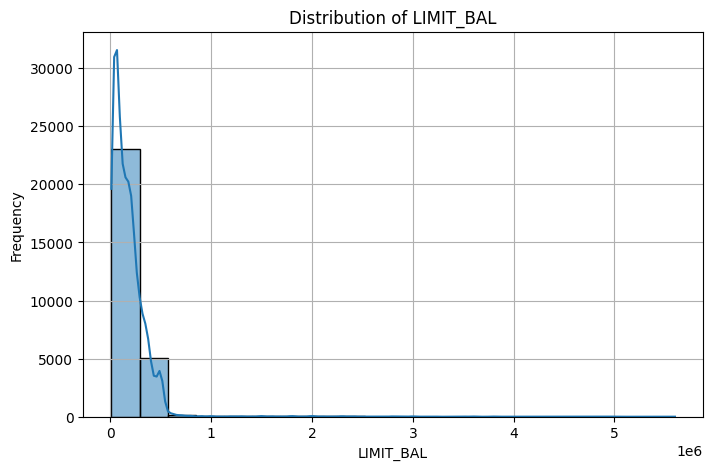

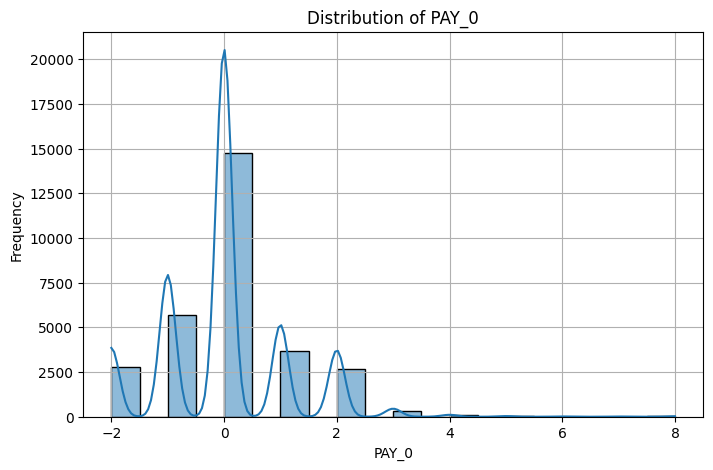

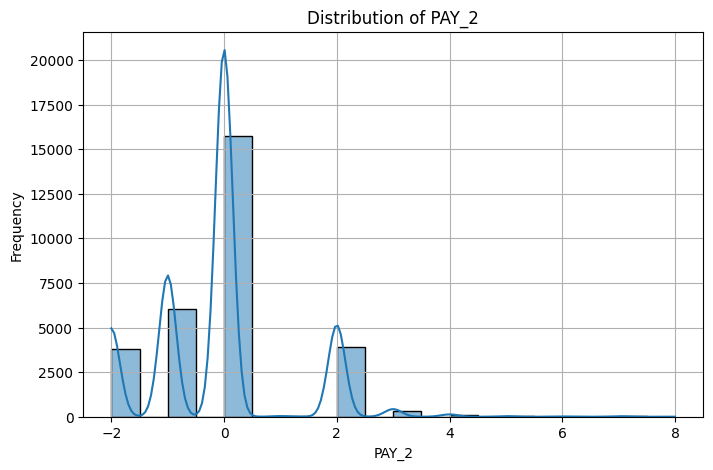

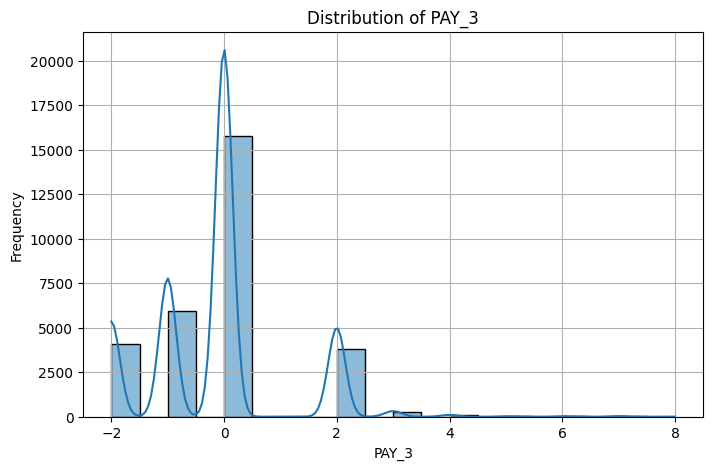

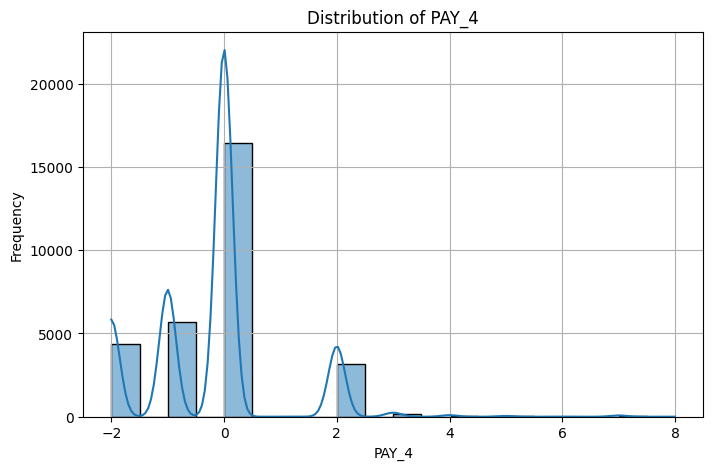

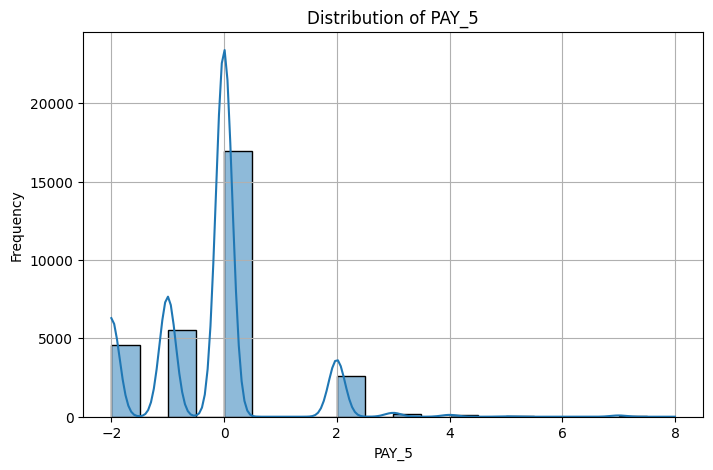

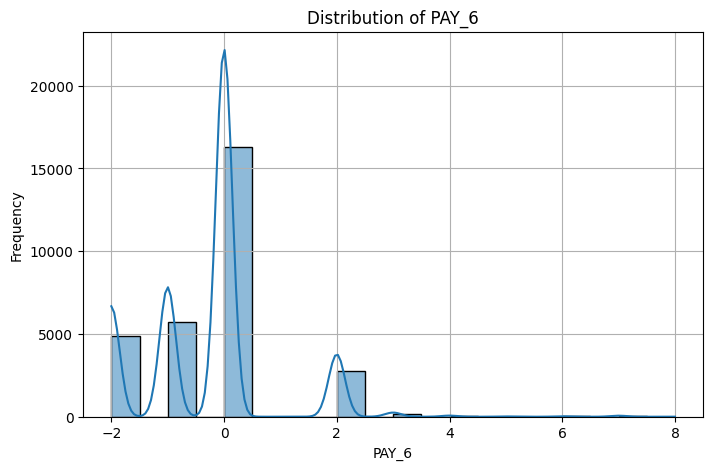

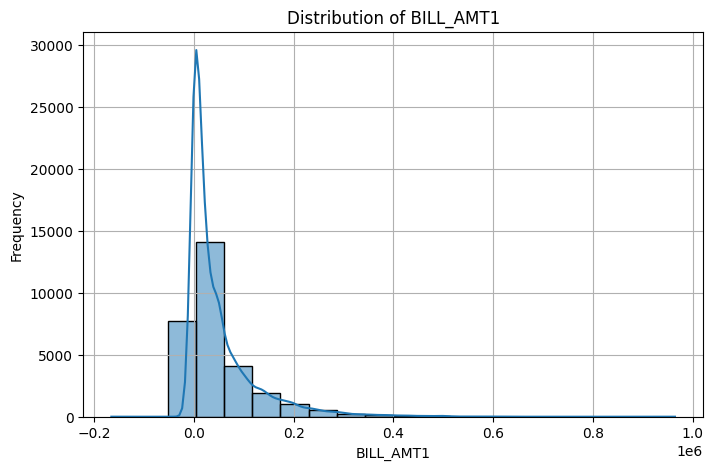

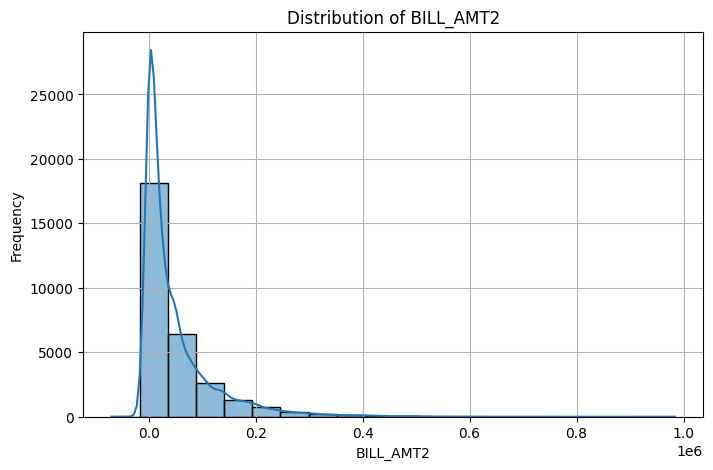

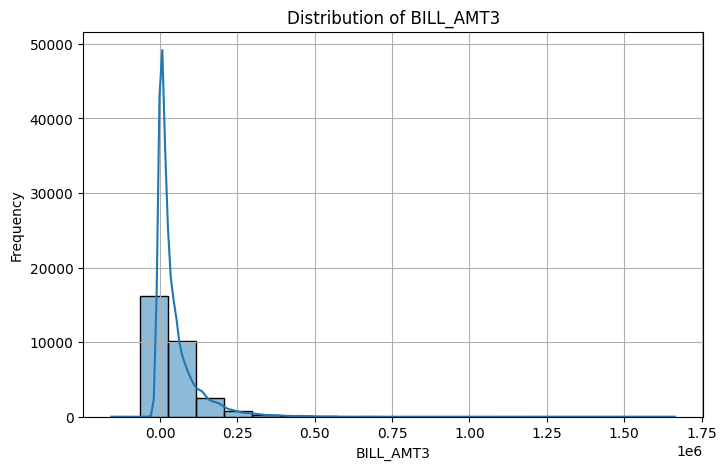

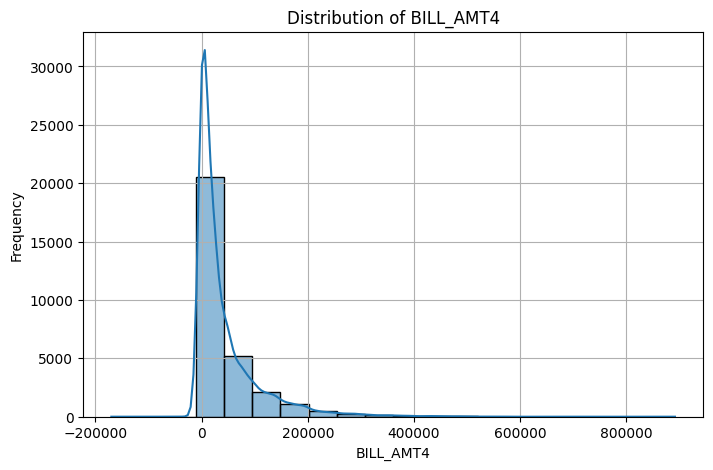

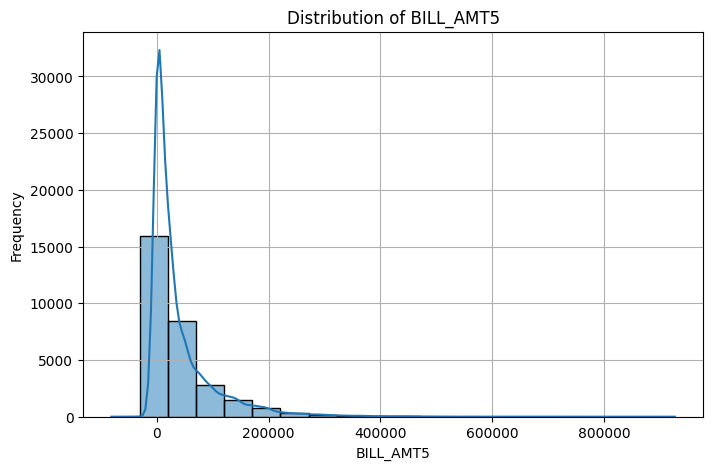

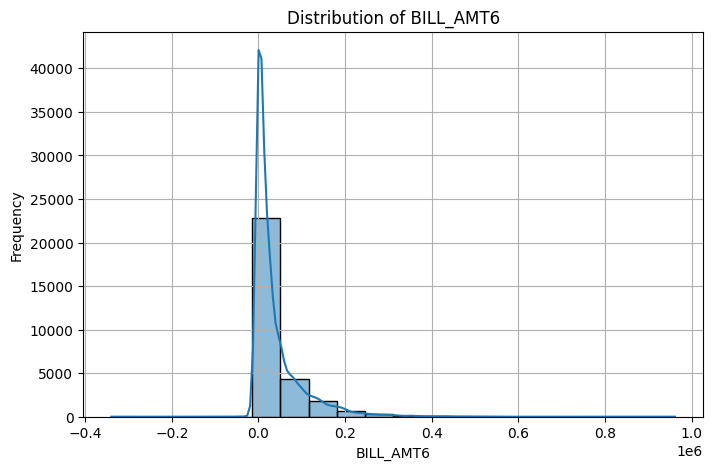

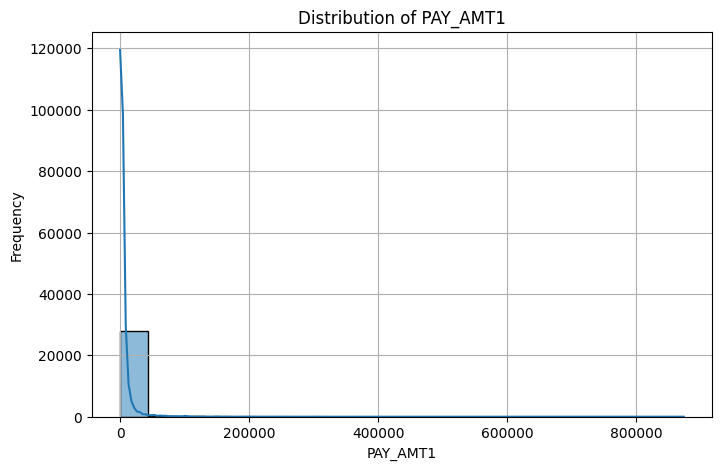

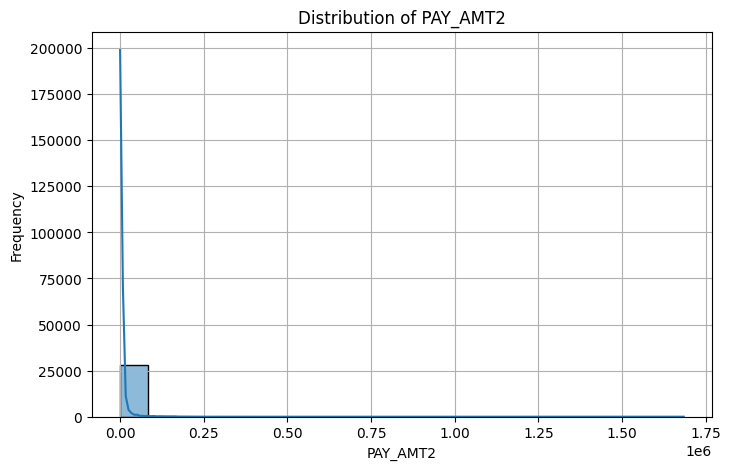

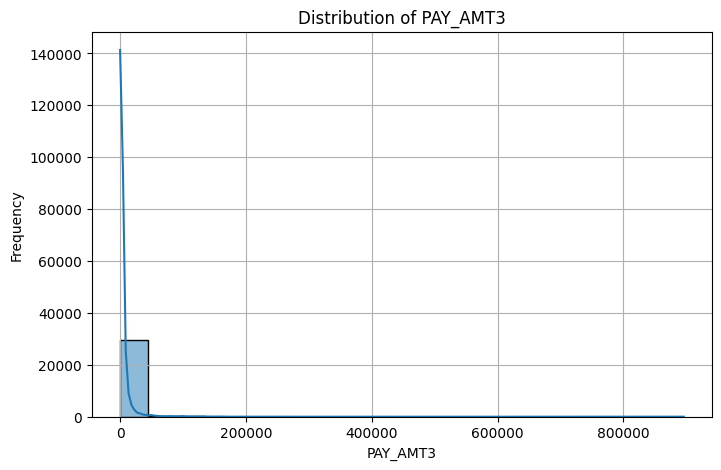

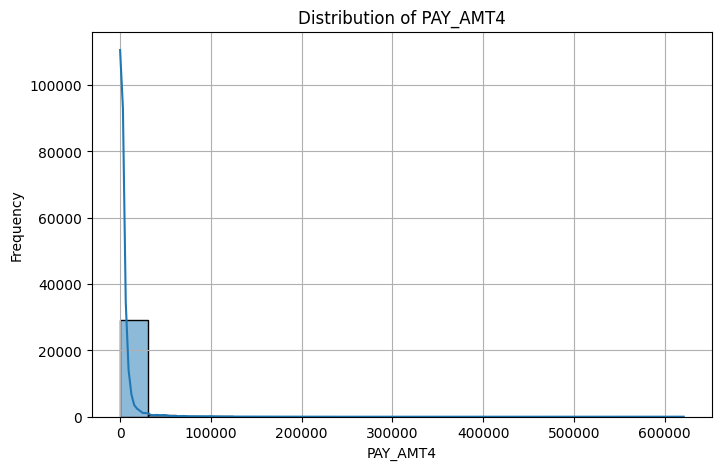

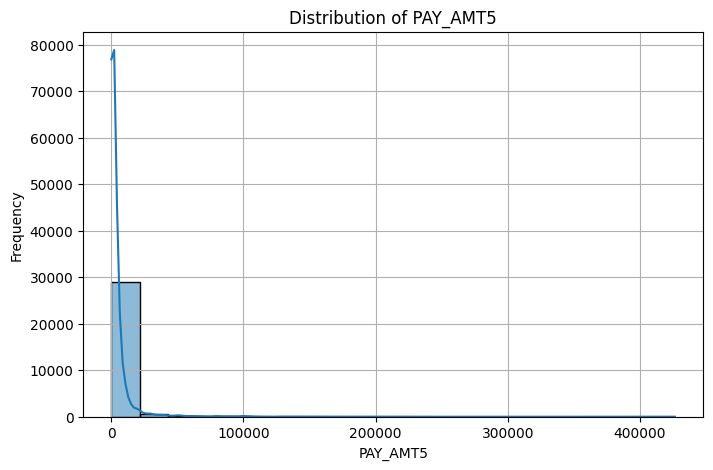

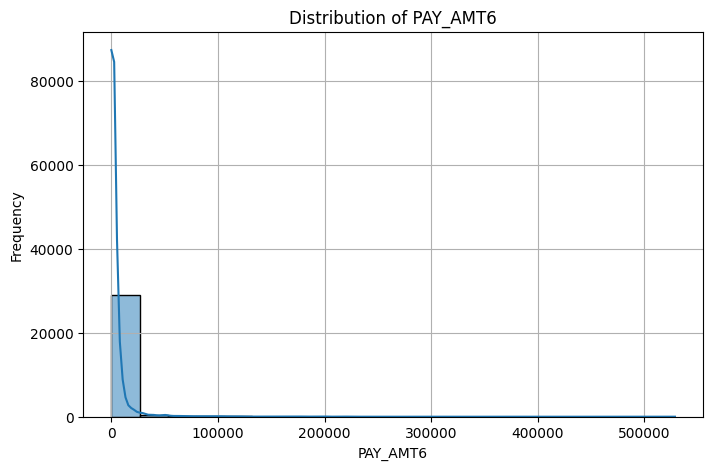

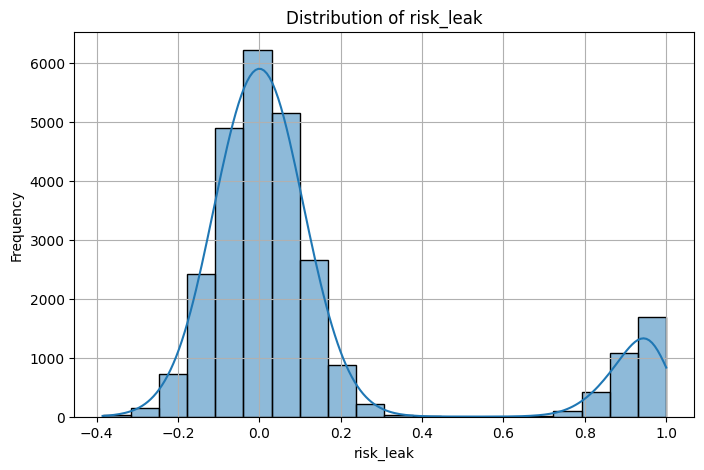

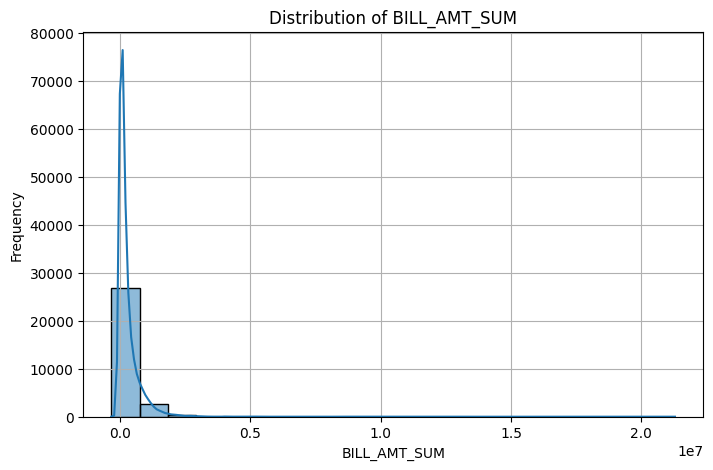

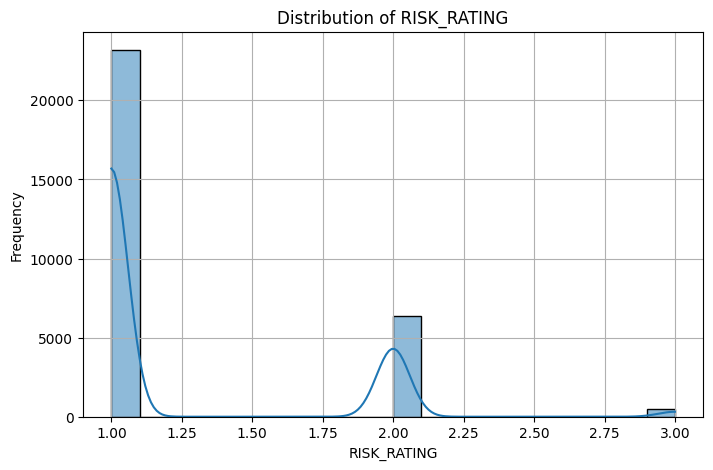

In [9]:
#ISSUE NUMBER 4
import seaborn as sns

Numerical_features = ['LIMIT_BAL','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
                   'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
                   'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','risk_leak',
                   'BILL_AMT_SUM','RISK_RATING'
                   ]

for column in Numerical_features:
    plt.figure()
    sns.histplot(df_copy[column], bins=20, kde=True, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [10]:
#ISSUE NUMBER 5
Q1 = df_copy[Numerical_features].quantile(0.25)
Q3 = df_copy[Numerical_features].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((df_copy[Numerical_features] < (Q1 - 1.5 * IQR)) | (df_copy[Numerical_features] > (Q3 + 1.5 * IQR))).sum()
outliers_count_specified

,0
LIMIT_BAL,390
PAY_0,3130
PAY_2,4410
PAY_3,4209
PAY_4,3508
PAY_5,2968
PAY_6,3079
BILL_AMT1,2400
BILL_AMT2,2395
BILL_AMT3,2469


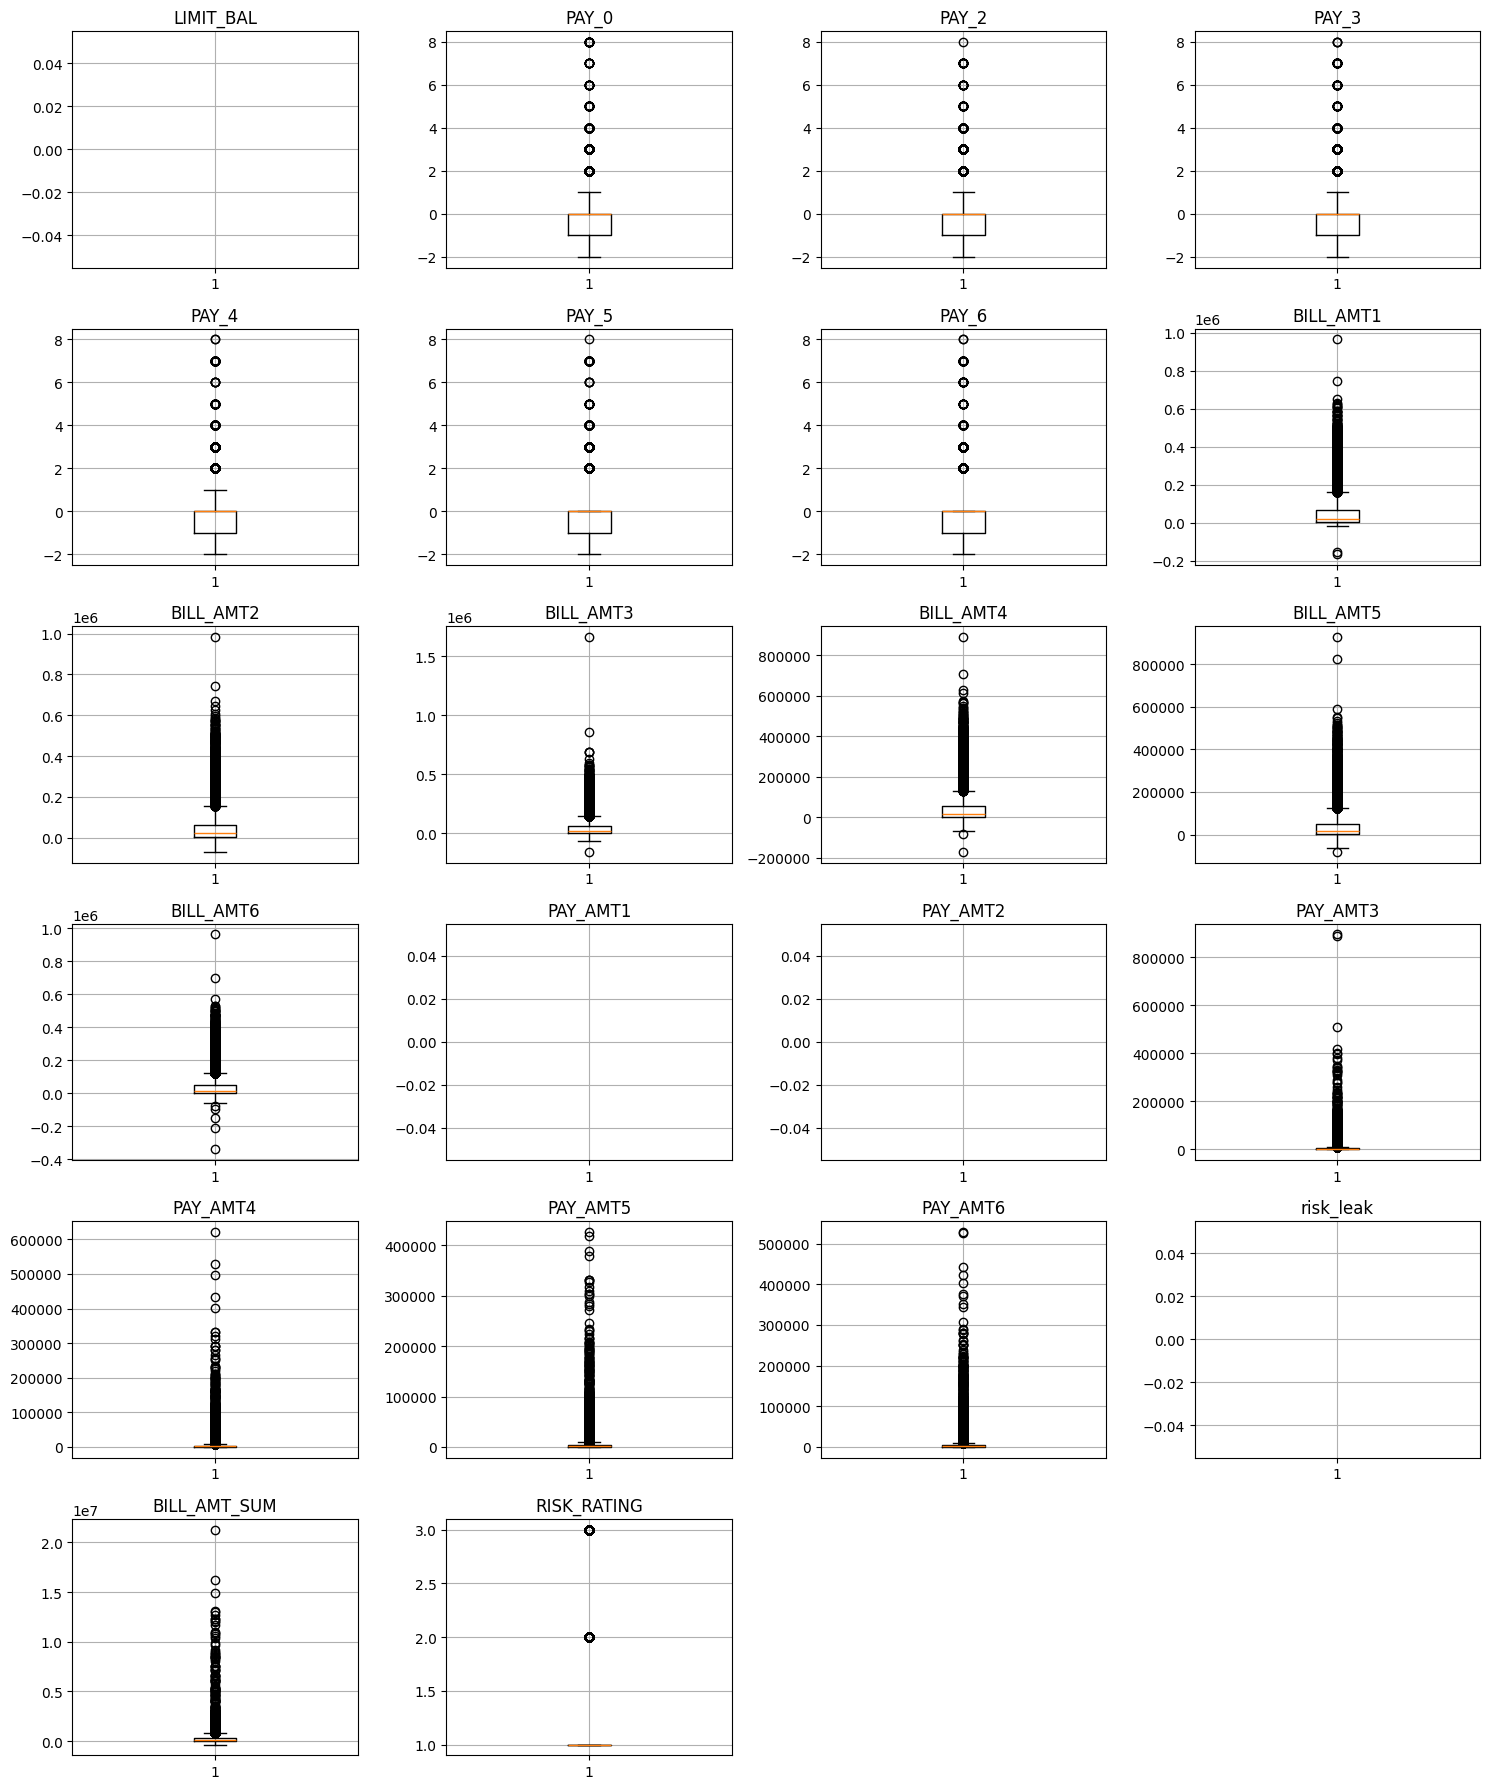

In [11]:
#ISSUE NUMBER 5
plt.figure(figsize=(15, 18))
for i, col in enumerate(Numerical_features):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(df_copy[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
X = df_copy.drop(['default.payment.next.month','ID', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE','CITY','risk_leak','LIMIT_BAL_LOG'], axis=1)
y = df_copy['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

Numerical_features = X_train_fe.select_dtypes(include=["number"]).columns.tolist()
print(Numerical_features)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("yeo-johnson", PowerTransformer(method="yeo-johnson",standardize=False)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, Numerical_features)
])

['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT_SUM', 'RISK_RATING']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42, max_depth=5))
])

forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=42))
])

log_reg_model.fit(X_train_fe, y_train)
tree_model.fit(X_train_fe, y_train)
forest_model.fit(X_train_fe, y_train)
gb_model.fit(X_train_fe, y_train)
xgb_model.fit(X_train_fe, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('yeo-johnson',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PA...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

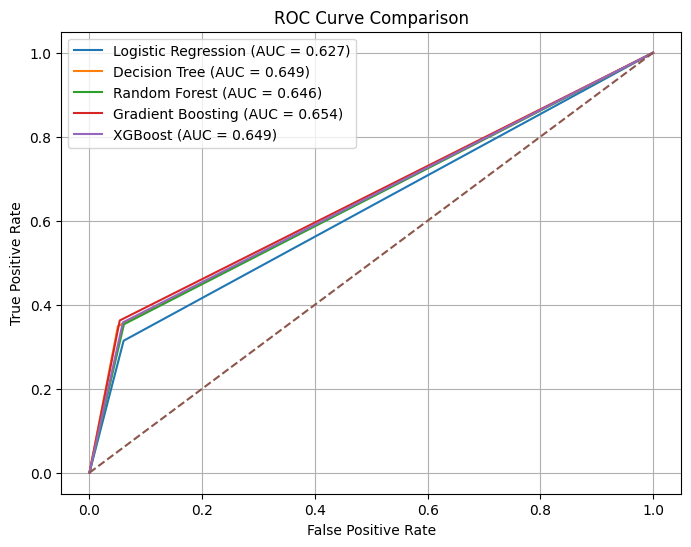

,Model,Accuracy
3,Gradient Boosting,0.817167
1,Decision Tree,0.816667
4,XGBoost,0.811833
2,Random Forest,0.809333
0,Logistic Regression,0.801167


In [15]:
models = {
    "Logistic Regression": log_reg_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

results = []

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred = model.predict(X_test_fe)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    fpr, tpr, _ = roc_curve(y_test, y_pred)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_fe)

print(f"Best model: {best_model_name}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

Best model: Gradient Boosting

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

Confusion matrix:
[[4422  251]
 [ 846  481]]
